# Bandpass filtering noise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/bandpassfiltering_noise.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-26*

## Learning objectives

- See that filtering white noise to a narrow band of frequencies makes the resulting time series **look periodic**, even though no periodicity was present in the input.
- Practice computing the FFT of a signal, identifying the relevant Fourier coefficients, and verifying variance is preserved (Parseval's theorem).
- Zero out a chosen band of Fourier coefficients on both sides of the spectrum and invert with `np.fft.ifft` to recover the filtered time series.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

# Seed for reproducibility; use a Generator (modern numpy API).
SEED = 655
rng = np.random.default_rng(SEED)


## Generate white-noise data

Draw 1000 samples from a standard normal distribution — a discrete realization of white noise.

In [2]:
x = rng.normal(size=1000)


Plot the full time series so we can see what white noise looks like before any filtering.

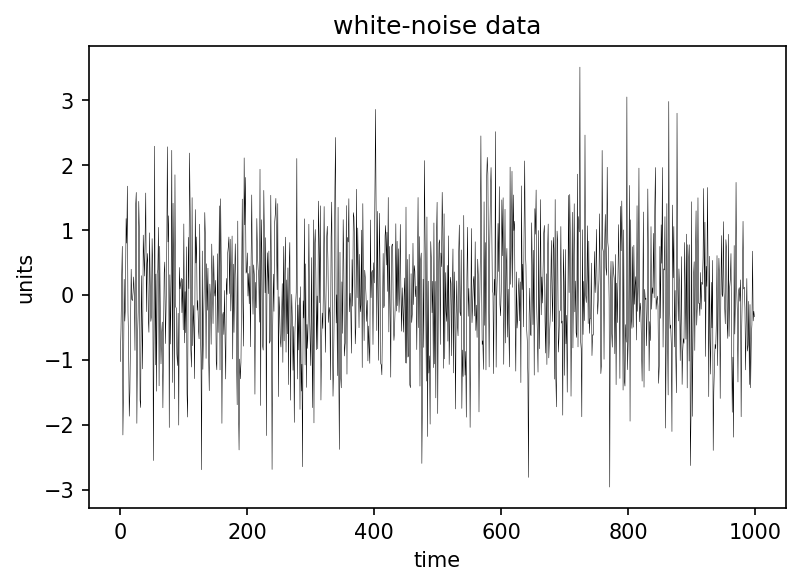

In [3]:
plt.figure()
plt.plot(np.arange(x.size), x, "-k", linewidth=0.25)
plt.ylabel("units")
plt.xlabel("time")
plt.title("white-noise data")
plt.show()


## Compute the FFT

Take the FFT and normalize by the length of the time series. The normalization matters for variance accounting; it should be skipped if you plan to feed the coefficients back into `np.fft.ifft`.

In [4]:
Z = np.fft.fft(x)
Yfft = Z / x.size


## Plot the power spectrum

Use `np.fft.rfftfreq` for the (one-sided) frequency axis and form normalized power $C_k^2$ from the first half of the Fourier coefficients. The factor of 2 keeps the spectrum-summed variance equal to the time-series variance.

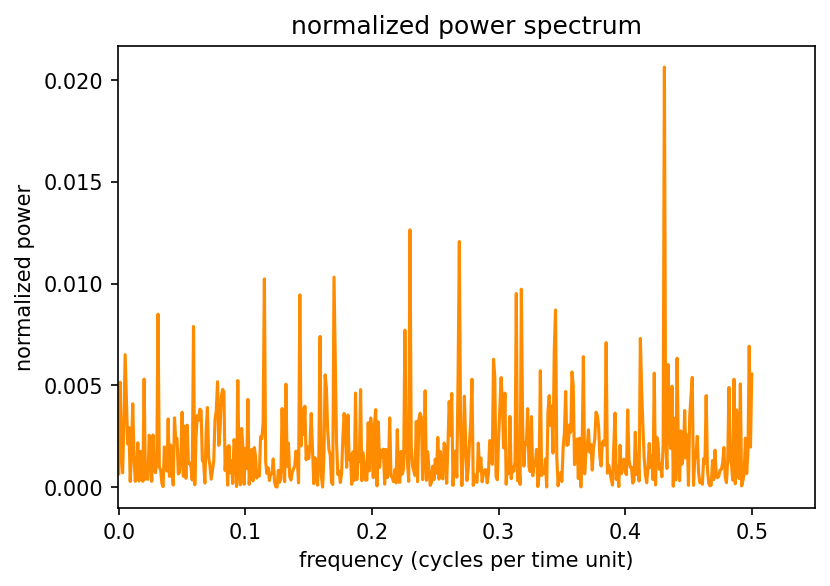

In [5]:
freq = np.fft.rfftfreq(x.size)
Ck2 = 2.0 * np.abs(Yfft[: x.size // 2 + 1]) ** 2

plt.figure()
plt.plot(freq, Ck2 / np.sum(Ck2), "-", color="darkorange", label="original spectrum")
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per time unit)")
plt.xlim(-0.001, 0.55)
plt.title("normalized power spectrum")
plt.show()


Check Parseval's theorem: the variance computed in time space should match the variance computed by summing $|Y_k|^2$ across frequencies (excluding the mean component).

In [6]:
var_actual = np.var(x)

a = Yfft[: x.size // 2 + 1]
var_spectrum = np.real(2 * np.sum(a[1:] * np.conj(a[1:])))

print(f"variance actual   = {var_actual:.5f}")
print(f"variance spectrum = {var_spectrum:.5f}")


variance actual   = 0.97334
variance spectrum = 0.97605


## Pick a frequency band to retain

Highlight the band of frequencies (indices 100–170) we will keep after filtering. Everything outside this band will be zeroed out.

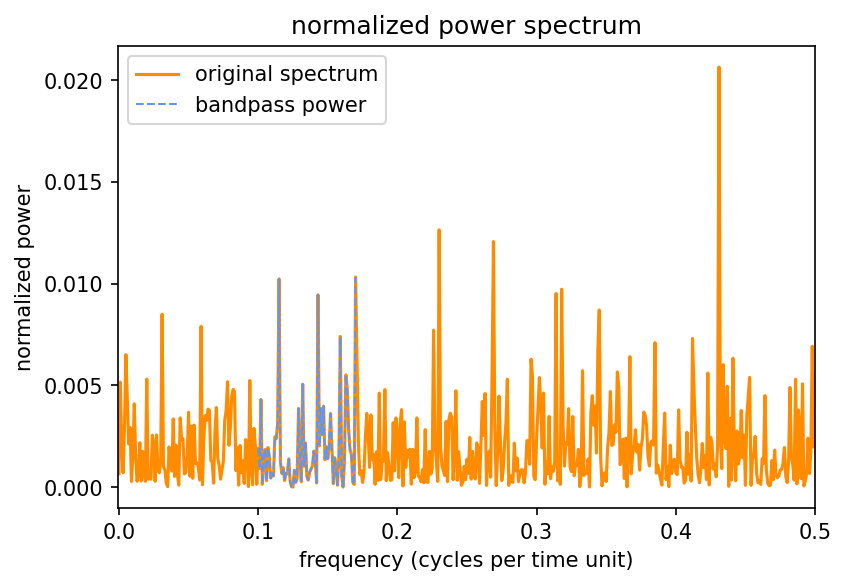

In [7]:
plt.figure()
plt.plot(freq, Ck2 / np.sum(Ck2), "-", color="darkorange", label="original spectrum")
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per time unit)")
plt.xlim(-0.001, 0.5)
plt.title("normalized power spectrum")

A = Ck2 / np.sum(Ck2)
A[:100] = 0.0
A[171:] = 0.0
plt.plot(
    freq[100:171],
    A[100:171],
    "--",
    color="cornflowerblue",
    linewidth=1,
    label="bandpass power",
)

plt.legend()
plt.show()


## Bandpass filter in frequency space

`Z` (the FFT of `x`) is symmetric, so the band must be zeroed on **both** sides of the spectrum. We then invert with `np.fft.ifft` to return to time space.

In [8]:
Zlow = np.copy(Z)
Zlow[:100] = 0.0
Zlow[171:-171] = 0.0
Zlow[-100:] = 0.0
print(f"number of non-zero values = {np.count_nonzero(Zlow)}")

x_filtered = np.real(np.fft.ifft(Zlow))


number of non-zero values = 142


## Plot the filtered time series

Show the bandpass-filtered series in full and zoomed in. Notice the smooth, near-periodic oscillation that has appeared.

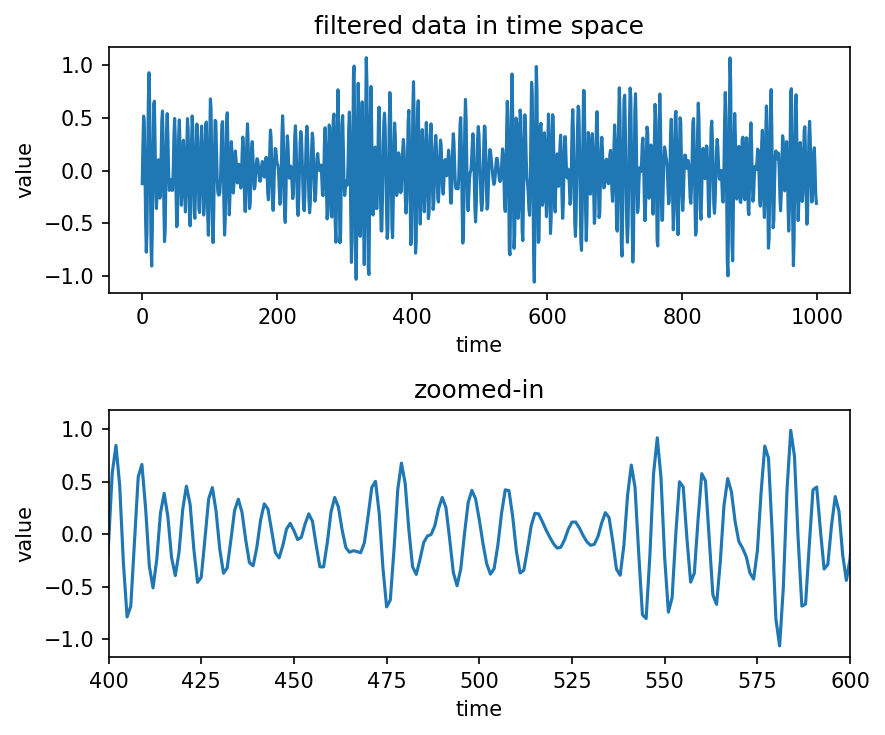

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(6, 5))

axes[0].plot(x_filtered, "-")
axes[0].set_title("filtered data in time space")
axes[0].set_xlabel("time")
axes[0].set_ylabel("value")

axes[1].plot(x_filtered, "-")
axes[1].set_title("zoomed-in")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].set_xlim(400, 600)

plt.tight_layout()
plt.show()


## Take-home point

The filtered series *looks* periodic even though the input was white noise with no periodicity at all. Bandpass filtering selects a narrow range of Fourier modes; the inverse transform of a few modes is, by construction, almost sinusoidal. So if you bandpass-filter your data and then "discover" an oscillation, ask yourself whether the oscillation was in the data or in the filter.